In [1]:
import understatapi
import pandas as pd

# Initialize the client class to access data from understat
client = understatapi.UnderstatClient()


In [2]:
# accessing league data
league_data = client.league(league = 'La_Liga').get_match_data(season = '2025')

In [3]:
league_data[25]

{'id': '29183',
 'isResult': True,
 'h': {'id': '223', 'title': 'Girona', 'short_title': 'GIR'},
 'a': {'id': '138', 'title': 'Sevilla', 'short_title': 'SEV'},
 'goals': {'h': '0', 'a': '2'},
 'xG': {'h': '2.00908', 'a': '1.62032'},
 'datetime': '2025-08-30 17:30:00',
 'forecast': {'w': '0.4833', 'd': '0.2544', 'l': '0.2623'}}

In [4]:
# shot data

shot_data = client.match(match='29183').get_shot_data()
shot_data['h'][5]

{'id': '640535',
 'minute': '51',
 'result': 'BlockedShot',
 'X': '0.9019999694824219',
 'Y': '0.51',
 'xG': '0.07823160290718079',
 'player': 'Vitor Reis',
 'h_a': 'h',
 'player_id': '13380',
 'situation': 'FromCorner',
 'season': '2025',
 'shotType': 'Head',
 'match_id': '29183',
 'h_team': 'Girona',
 'a_team': 'Sevilla',
 'h_goals': '0',
 'a_goals': '2',
 'date': '2025-08-30 17:30:00',
 'player_assisted': 'Thomas Lemar',
 'lastAction': 'Cross'}

In [5]:
player_data = client.player(player='13380').get_shot_data()
dff = pd.DataFrame(player_data)
dff

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
0,640535,51,BlockedShot,0.9019999694824219,0.51,0.07823160290718079,Vitor Reis,h,13380,FromCorner,2025,Head,29183,Girona,Sevilla,0,2,2025-08-30 17:30:00,Thomas Lemar,Cross
1,640548,91,BlockedShot,0.9009999847412109,0.505,0.027078725397586823,Vitor Reis,h,13380,FromCorner,2025,Head,29183,Girona,Sevilla,0,2,2025-08-30 17:30:00,Portu,Aerial
2,640552,93,MissedShots,0.705999984741211,0.615,0.00791599228978157,Vitor Reis,h,13380,OpenPlay,2025,RightFoot,29183,Girona,Sevilla,0,2,2025-08-30 17:30:00,None,Rebound
3,655948,70,MissedShots,0.93,0.40700000762939453,0.1584821343421936,Vitor Reis,h,13380,SetPiece,2025,Head,29290,Girona,Real Madrid,1,1,2025-11-30 20:00:00,Azz-Eddine Ounahi,Cross
4,659676,22,MissedShots,0.9119999694824219,0.6029999923706054,0.07282660156488419,Vitor Reis,h,13380,SetPiece,2025,RightFoot,29324,Girona,Atletico Madrid,0,3,2025-12-21 13:00:00,None,None
5,665671,20,SavedShot,0.9309999847412109,0.4640000152587891,0.06212350353598595,Vitor Reis,h,13380,FromCorner,2025,Head,29365,Girona,Getafe,1,1,2026-01-26 20:00:00,Bryan Gil Salvatierra,Aerial
6,665685,87,MissedShots,0.8490000152587891,0.5509999847412109,0.022557714954018593,Vitor Reis,h,13380,OpenPlay,2025,Head,29365,Girona,Getafe,1,1,2026-01-26 20:00:00,Daley Blind,Cross
7,665686,93,Goal,0.925,0.4859999847412109,0.4147642254829407,Vitor Reis,h,13380,OpenPlay,2025,Head,29365,Girona,Getafe,1,1,2026-01-26 20:00:00,Álex Moreno,Cross


In [6]:
dff[['situation','shotType']]

,situation,shotType
0,FromCorner,Head
1,FromCorner,Head
2,OpenPlay,RightFoot
3,SetPiece,Head
4,SetPiece,RightFoot
5,FromCorner,Head
6,OpenPlay,Head
7,OpenPlay,Head


In [7]:
import pandas as pd
from understatapi import UnderstatClient

# Using the context manager (the 'with' thing we discussed)
with UnderstatClient() as understat:
    
    # 1. Access the League Endpoint for EPL
    # 2. Call the method to get player data for 2023
    data = understat.league(league="EPL").get_player_data(season="2023")

# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(data)
# Convert 'goals' column to numbers so we can sort (data starts as strings)
df['goals'] = pd.to_numeric(df['goals'])

# Select columns and show the top 5 scorers
top_scorers = df[['player_name', 'team_title', 'goals']].sort_values(by='goals', ascending=False)
top_5_goalscorers = pd.DataFrame(top_scorers.head(5))
top_5_goalscorers




,player_name,team_title,goals
0,Erling Haaland,Manchester City,27
1,Cole Palmer,"Chelsea,Manchester City",22
2,Alexander Isak,Newcastle United,21
3,Dominic Solanke,Bournemouth,19
4,Phil Foden,Manchester City,19


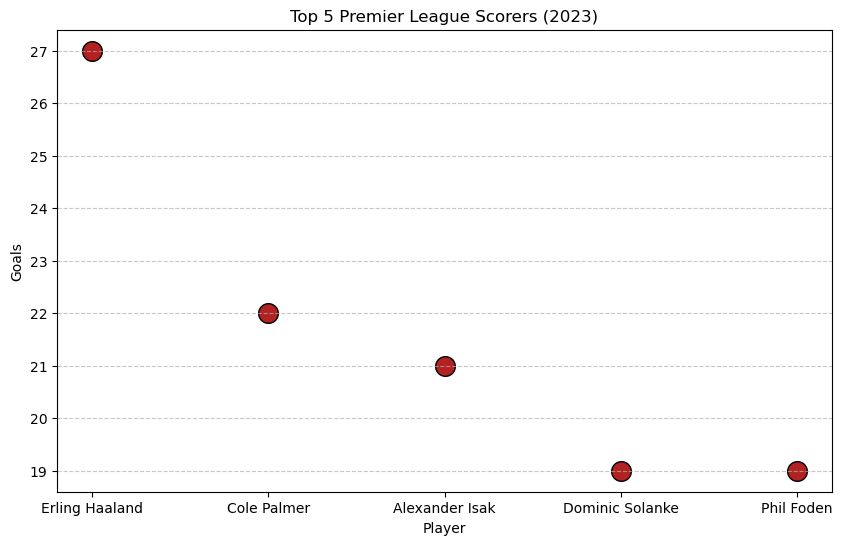

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(top_5_goalscorers['player_name'], top_5_goalscorers['goals'], s=200, color='firebrick', edgecolors='black')
plt.title('Top 5 Premier League Scorers (2023)')
plt.xlabel('Player')
plt.ylabel('Goals')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
